# Autoregressive Image Generation

In [1]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math
import os
from tqdm import tqdm
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using cuda


## VQ-VAE

A VQ-VAE compresses images into a grid of discrete tokens. The encoder maps an image to a continuous spatial latent; the vector quantizer replaces each spatial position with the nearest entry in a learned codebook; the decoder reconstructs the image from the quantized codes. The discrete bottleneck is what makes the latent space compatible with autoregressive modeling — once images are tokens, a transformer can model their distribution.

### Residual Block

Each residual block applies two convolutions with normalization, then adds the result back to its input. The network only needs to learn the correction on top of the identity — if no refinement is needed the block can output zeros. Two blocks are stacked in both the encoder and decoder at the $8 \times 8$ bottleneck resolution.

In [3]:
class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(d, d, 3, padding=1),
            nn.GroupNorm(8, d),
            nn.ReLU(),
            nn.Conv2d(d, d, 3, padding=1),
            nn.GroupNorm(8, d),
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.block(x))

### Encoder

Two strided convolutions downsample the image by 4×, then two residual blocks refine the representation at the $8 \times 8$ bottleneck before quantization.

In [4]:
class Encoder(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.conv1 = nn.Conv2d(3, d, 4, padding=1, stride=2)
        self.conv2 = nn.Conv2d(d, d, 4, padding=1, stride=2)
        self.act   = nn.ReLU()
        self.res1  = ResBlock(d)
        self.res2  = ResBlock(d)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.res1(x)
        x = self.res2(x)
        return x

### Decoder

Two residual blocks first refine the quantized representation at the $8 \times 8$ resolution, then transposed convolutions upsample back to the original size. The output has no activation — pixel values are unconstrained and normalized at training time.

In [5]:
class Decoder(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.res1   = ResBlock(d)
        self.res2   = ResBlock(d)
        self.convt1 = nn.ConvTranspose2d(d, d, 4, padding=1, stride=2)
        self.convt2 = nn.ConvTranspose2d(d, 3, 4, padding=1, stride=2)
        self.act    = nn.ReLU()

    def forward(self, x):
        x = self.res1(x)
        x = self.res2(x)
        x = self.act(self.convt1(x))
        x = self.convt2(x)
        return x

### Vector Quantizer

For each spatial position, the quantizer replaces the encoder output with the nearest codebook entry:

$$z_q = e_{\,\arg\min_k \|z_e - e_k\|}$$

Gradients cannot flow through $\arg\min$, so the straight-through estimator is used: the forward pass uses $z_q$ while gradients flow back through $z_e$ as if no quantization occurred.

The codebook is updated by exponential moving average rather than gradient. After each batch, for each entry $e_k$, the running sum of assigned encoder outputs and the assignment count are updated:

$$m_k \leftarrow \gamma m_k + (1-\gamma)\sum_{i \to k} z_e^{(i)}, \qquad n_k \leftarrow \gamma n_k + (1-\gamma)|\{i \to k\}|$$

then $e_k \leftarrow m_k / n_k$. Old assignments decay geometrically, so each entry tracks the centroid of recently assigned outputs. Dead codes are revived by replacing them with encoder outputs from the current batch.

In [6]:
class VectorQuantizer(nn.Module):
    def __init__(self, K=128, d=32, gamma=0.99, eps=1e-5, dead_threshold=1.0):
        super().__init__()
        self.K              = K
        self.d              = d
        self.gamma          = gamma
        self.eps            = eps
        self.dead_threshold = dead_threshold

        self.register_buffer('codebook',         torch.randn(K, d))
        self.register_buffer('ema_cluster_size', torch.zeros(K))
        self.register_buffer('ema_embed_sum',    torch.randn(K, d))

    def forward(self, z_e):
        B, C, H, W = z_e.shape
        z_e_flat = z_e.view(B, C, -1).transpose(1, 2).contiguous()  # (B, H*W, d)

        dists = torch.cdist(z_e_flat, self.codebook)     # (B, H*W, K)
        idx   = torch.argmin(dists, dim=2)               # (B, H*W)

        if self.training:
            with torch.no_grad():
                one_hot = torch.zeros(idx.numel(), self.K, device=z_e.device)
                one_hot.scatter_(1, idx.view(-1, 1), 1)

                n_k = one_hot.sum(0)
                self.ema_cluster_size = self.gamma * self.ema_cluster_size \
                                      + (1 - self.gamma) * n_k

                dw = one_hot.t() @ z_e_flat.view(-1, self.d)
                self.ema_embed_sum = self.gamma * self.ema_embed_sum \
                                   + (1 - self.gamma) * dw

                n        = self.ema_cluster_size.sum()
                n_smooth = (self.ema_cluster_size + self.eps) \
                         / (n + self.K * self.eps) * n
                self.codebook = self.ema_embed_sum / n_smooth.view(self.K, 1)

                dead   = self.ema_cluster_size < self.dead_threshold
                n_dead = dead.sum().item()
                if n_dead > 0:
                    perm = torch.randperm(z_e_flat.shape[0] * z_e_flat.shape[1], device=z_e.device)[:n_dead]
                    self.codebook[dead] = z_e_flat.view(-1, self.d)[perm]

        z_q = self.codebook[idx]                          # (B, H*W, d)
        z_q = z_q.transpose(1, 2).contiguous().view(B, C, H, W)

        z_q_st = z_e + (z_q - z_e).detach()
        return z_q_st, z_q, idx.view(B, H, W)

In [7]:
class VQVAE(nn.Module):
    def __init__(self, K=128, d=32):
        super().__init__()
        self.enc = Encoder(d)
        self.vq  = VectorQuantizer(K, d)
        self.dec = Decoder(d)

    def forward(self, x):
        z_e              = self.enc(x)
        z_q_st, z_q, idx = self.vq(z_e)
        x_hat            = self.dec(z_q_st)
        return x_hat, z_e, z_q, idx

## VQ-VAE Training

Two losses: reconstruction and commitment. The codebook itself is updated by EMA, not gradient:

$$\mathcal{L} = \|x - \hat{x}\|^2 + \beta\,\|z_q - z_e\|^2$$

The commitment term encourages the encoder output to stay close to its assigned code. $\beta$ is small — the EMA update is already a stable objective, so the commitment loss mainly stabilizes the encoder.

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset    = torchvision.datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [9]:
K = 512
d = 64
beta = 0.25

model     = VQVAE(K=K, d=d).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-5)
loss_fn   = nn.MSELoss()

In [10]:
import os
if os.path.exists('data/vqvae_cifar10_latest.pt'):
    model.load_state_dict(torch.load('data/vqvae_cifar10_latest.pt', map_location=device))
    print('loaded checkpoint')
else:
    print('no checkpoint found, training from scratch')

loaded checkpoint


In [ ]:
epochs = 10  # re-run this cell to train another chunk
losses = []
codebook_utils = []

for epoch in range(epochs):
    epoch_loss = 0.0
    all_idx    = []
    pbar = tqdm(dataloader, desc=f'epoch {epoch+1}/{epochs}', leave=False)
    for x, _ in pbar:
        x     = x.to(device)
        x_hat, z_e, z_q, idx = model(x)
        l_recon  = loss_fn(x_hat, x)
        l_commit = loss_fn(z_q.detach(), z_e)
        loss     = l_recon + beta * l_commit

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        all_idx.append(idx.cpu())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = epoch_loss / len(dataloader)
    util     = torch.cat([i.flatten() for i in all_idx]).unique().numel()
    losses.append(avg_loss)
    codebook_utils.append(util)
    print(f'epoch {epoch+1:2d}  loss {avg_loss:.4f}  codebook util {util}/{K}')

from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M')
torch.save(model.cpu().state_dict(), f'data/vqvae_cifar10_{ts}.pt')
torch.save(model.cpu().state_dict(), 'data/vqvae_cifar10_latest.pt')
model.to(device)
print(f'saved vqvae_cifar10_{ts}.pt')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(losses);         ax1.set_xlabel('epoch'); ax1.set_title('loss (this chunk)')
ax2.plot(codebook_utils); ax2.set_xlabel('epoch'); ax2.set_title('codebook utilization')
plt.tight_layout()
plt.show()

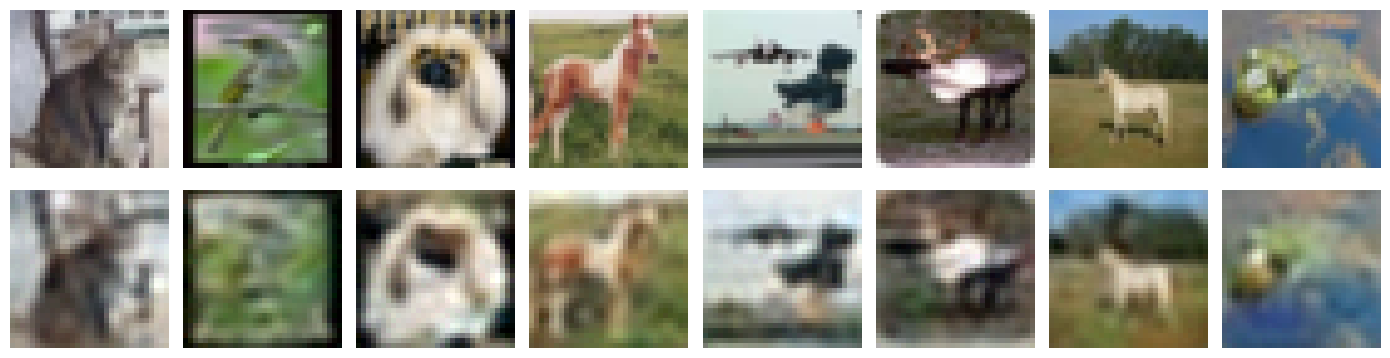

VQVAE(
  (enc): Encoder(
    (conv1): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (act): ReLU()
    (res1): ResBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
      )
      (act): ReLU()
    )
    (res2): ResBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
      )
      (act): ReLU()
    )
  )
  (vq): VectorQuantizer()
  (dec): Decoder(
    (res1): Re

In [14]:
model.eval()
x_orig, _ = next(iter(dataloader))
x_orig = x_orig[:8].to(device)
with torch.no_grad():
    x_hat, _, _, _ = model(x_orig)
x_orig = (x_orig.cpu() + 1) / 2
x_hat  = (x_hat.cpu()  + 1) / 2
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(x_orig[i].permute(1, 2, 0).clamp(0, 1)); axes[0, i].axis('off')
    axes[1, i].imshow(x_hat[i].permute(1, 2, 0).clamp(0, 1));  axes[1, i].axis('off')
axes[0, 0].set_ylabel('original',      fontsize=10)
axes[1, 0].set_ylabel('reconstructed', fontsize=10)
plt.tight_layout()
plt.show()
model.train()

## Autoregressive Transformer

The transformer models the joint distribution over codebook token sequences autoregressively: given the class label and all previous tokens, predict the next. At generation time, tokens are sampled one by one left-to-right, top-to-bottom, then decoded by the VQ-VAE decoder.

### 2D Positional Encoding

Tokens come from an 8×8 spatial grid — a flat index carries no spatial meaning on its own. We decompose each position into its row and column and encode each independently with sinusoidal embeddings, then concatenate. This gives the transformer a sense of both axes without conflating them.

In [15]:
def positional_encoding(pos, n_cols, d_model):
    d = d_model // 2
    half = d // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half) / half)  # CPU
    row_pos = pos // n_cols
    col_pos = pos % n_cols
    row_args = row_pos.float().view(-1, 1) @ freqs.view(1, -1)
    col_args = col_pos.float().view(-1, 1) @ freqs.view(1, -1)
    return torch.cat([row_args.sin(), row_args.cos(), col_args.sin(), col_args.cos()], dim=1)

### GPT

The transformer factorizes the joint distribution autoregressively:

$$p(t_1, \ldots, t_N \mid c) = \prod_{i=1}^{N} p(t_i \mid c,\, t_1, \ldots, t_{i-1})$$

The class label $c$ is prepended as the first token via a learned embedding. A causal (lower-triangular) mask ensures each position attends only to earlier ones. The transformer predicts a distribution over the $K$-entry codebook at each position; during training the target at position $i$ is the actual token at position $i+1$.

In [16]:
class GPT(nn.Module):
    def __init__(self, K=512, S=8, d_model=256, nhead=8, num_layers=8):
        super().__init__()
        self.K = K
        self.token_emb = nn.Embedding(K, d_model)
        self.label_emb = nn.Embedding(10, d_model)
        pos_encoding = positional_encoding(torch.arange(0, S*S - 1), S, d_model)  # (S*S-1, d)
        self.register_buffer('pos_encoding', pos_encoding)
        self.register_buffer('mask', torch.tril(torch.ones(S*S, S*S, dtype=torch.bool)))  # (49, 49)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.linear = nn.Linear(d_model, K)

    def forward(self, seq):
        l_emb = self.label_emb(seq[:, :1])       # (B, 1, d)
        t_emb = self.token_emb(seq[:, 1:])       # (B, S*S-1, d)
        t_emb = t_emb + self.pos_encoding        # (S*S-1, d) — no slicing needed
        x    = torch.cat([l_emb, t_emb], dim=1)  # (B, S*S, d)
        out  = self.transformer(x, mask=self.mask, is_causal=True)
        return self.linear(out)                   # (B, S*S, K)

## Sampling

Generation runs the autoregressive loop: start with a class label token, then sample one token at a time using the GPT's predicted distribution. The full $8 \times 8 = 64$ token grid is then decoded by the VQ-VAE decoder into a $32 \times 32$ RGB image.

In [17]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
S = 8

@torch.no_grad()
def generate(labels, temperature=1.0):
    B = labels.shape[0]
    x = torch.cat([labels.view(B, 1), torch.zeros(B, S*S, dtype=torch.long, device=device)], dim=1)
    for i in tqdm(range(S*S), desc='generating'):
        logits = gpt(x[:, :-1])[:, i, :] / temperature
        probs  = nn.functional.softmax(logits, dim=1)
        x[:, i+1] = torch.multinomial(probs, 1).squeeze()
    z_q = vqvae.vq.codebook[x[:, 1:]]
    z_q = z_q.transpose(1, 2).contiguous().view(B, d, S, S)
    return (vqvae.dec(z_q) + 1) / 2

## Transformer Training

The VQ-VAE encoder is run once over the full dataset to produce token sequences, which are then stored and used to train the transformer. This avoids re-encoding images every epoch.

### Encode Dataset

Run the frozen VQ-VAE encoder once over all of CIFAR-10, saving $50{,}000$ token sequences of length $65$ — class label followed by 64 codebook indices from the $8 \times 8$ grid.

In [18]:
vqvae = VQVAE(K=512, d=64).to(device)
vqvae.load_state_dict(torch.load('data/vqvae_cifar10_latest.pt', map_location=device))
vqvae.eval()

encode_loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

all_seqs = []
with torch.no_grad():
    for x, labels in tqdm(encode_loader):
        x      = x.to(device)
        _, _, _, idx = vqvae(x)
        idx    = idx.view(x.shape[0], -1).cpu()
        labels = labels.unsqueeze(1)
        seq    = torch.cat([labels, idx], dim=1)
        all_seqs.append(seq)

all_seqs = torch.cat(all_seqs, dim=0)
torch.save(all_seqs, 'data/cifar10_tokens.pt')
print(f'saved: {all_seqs.shape}')

100%|██████████| 196/196 [00:07<00:00, 25.14it/s]


saved: torch.Size([50000, 65])


### Training Loop

In [19]:
all_seqs      = torch.load('data/cifar10_tokens.pt')
token_dataset = torch.utils.data.TensorDataset(all_seqs)
token_loader  = torch.utils.data.DataLoader(token_dataset, batch_size=128, shuffle=True)

In [20]:
gpt       = GPT(K=512, S=8, d_model=256, nhead=8, num_layers=8).to(device)
optimizer = torch.optim.Adam(gpt.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-5)
loss_fn   = nn.CrossEntropyLoss()

In [21]:
import os
if os.path.exists('data/gpt_cifar10_large_latest.pt'):
    gpt.load_state_dict(torch.load('data/gpt_cifar10_large_latest.pt', map_location=device))
    print('loaded checkpoint')
else:
    print('no checkpoint found, training from scratch')

loaded checkpoint


In [ ]:
max_epochs = 200
patience   = 10
min_delta  = 1e-4
best_loss  = float('inf')
no_improve = 0
losses     = []

for epoch in range(max_epochs):
    epoch_loss = 0.0
    pbar = tqdm(token_loader, desc=f'epoch {epoch+1}', leave=False)
    for (seq,) in pbar:
        seq    = seq.to(device)
        inp    = seq[:, :-1]
        target = seq[:, 1:]

        logits = gpt(inp)
        loss   = loss_fn(logits.transpose(1, 2), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg = epoch_loss / len(token_loader)
    losses.append(avg)
    print(f'epoch {epoch+1:3d}  loss {avg:.4f}')

    if avg < best_loss - min_delta:
        best_loss  = avg
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'converged at epoch {epoch+1}')
            break

from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M')
torch.save(gpt.cpu().state_dict(), f'data/gpt_cifar10_large_{ts}.pt')
torch.save(gpt.cpu().state_dict(), 'data/gpt_cifar10_large_latest.pt')
gpt.to(device)
print(f'saved gpt_cifar10_large_{ts}.pt')

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('cross-entropy loss')
plt.show()

generating: 100%|██████████| 64/64 [00:00<00:00, 92.36it/s] 


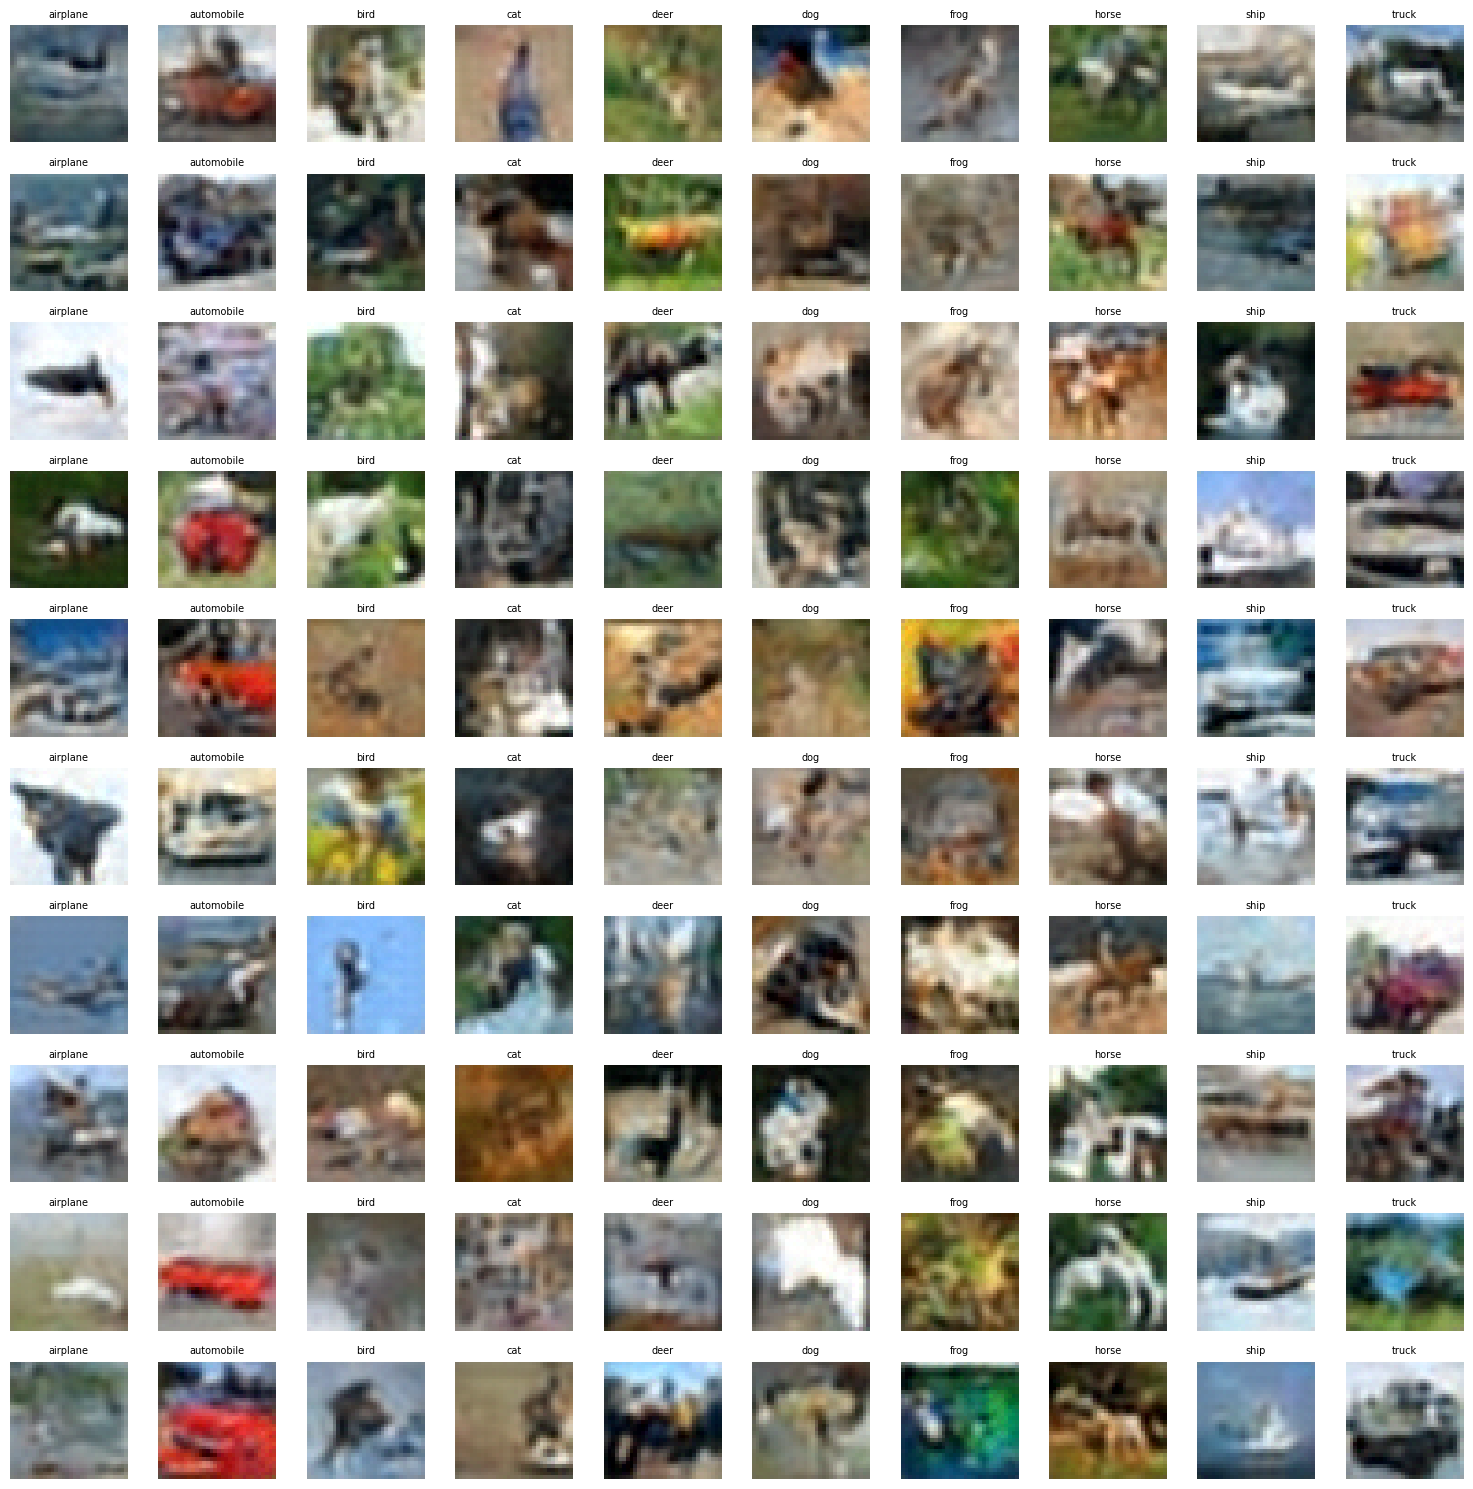

GPT(
  (token_emb): Embedding(512, 256)
  (label_emb): Embedding(10, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear): Linear(in_features=256, out_features=512, bias=True)
)

In [23]:
n = 10
labels = torch.arange(10, dtype=torch.long, device=device).repeat(n)
images = generate(labels)

fig, axes = plt.subplots(n, 10, figsize=(15, n * 1.5))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img.cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(CLASSES[label.item()], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
gpt.train()